# Información y Programación Financiera, TI, Algoritmos y Ciencia de Datos

Neftalí Valdez

<a href="http://twitter.com/neftalivldz" target="_blank">@neftalivldz</a> | <a href="mailto:nvaldez@tec.mx">nvaldez@tec.mx</a>

Basado en Community Detection & Network Analysis of the Stock Market in Python & R — Part 2
<a href="https://medium.com/analytics-vidhya/community-detection-network-analysis-of-the-stock-market-in-python-r-part-2-9b5a5dbe5d5b">link</a> 

In [29]:
#%pip install pandas_datareader
#%pip install networkx
#%pip install community

In [2]:
import lseg.data as ld
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
#plt.style.use('dark_background')
import warnings
warnings.filterwarnings('ignore')

from numpy.random import random, uniform, dirichlet, choice
from numpy.linalg import inv
from scipy.optimize import minimize
from matplotlib.ticker import FuncFormatter
import math
from datetime import datetime, timedelta
import pandas_datareader.data as web

In [3]:
ld.open_session()

<lseg.data.session.Definition object at 0x12bead370 {name='workspace'}>

In [4]:
lp4 = ld.get_data('LP40065886', ['TR.FundHoldingRIC','TR.FundHoldingName',
                           'TR.FundPercentageOfFundAssets',
                           'TR.FundNumberOfShares',
                           'TR.FundNumberOfSharesChanged'],
            {'Endnum':'5000'})

In [5]:
lp4.columns = [c.replace(' ', '_') for c in lp4.columns]
list_values = ['USD CASH', 'OTHER ASSETS LESS LIABILITIES']
portfolio = lp4[~lp4['Holding_Name'].isin(list_values)]['Holding_RIC'].to_list()
portfolio = portfolio[0:20]
portfolio

['NVDA.OQ',
 'AAPL.OQ',
 'MSFT.OQ',
 'AMZN.OQ',
 'GOOGL.OQ',
 'AVGO.OQ',
 'GOOG.OQ',
 'META.OQ',
 'TSLA.OQ',
 'BRKb.N',
 'LLY.N',
 'JPM.N',
 'XOM.N',
 'JNJ.N',
 'WMT.OQ',
 'V.N',
 'COST.OQ',
 'NFLX.OQ',
 'MA.N',
 'CVX.N']

In [6]:
#portfolio = ["GOLD.N", "TSLA.O", "GOOGL.O", 'MSFT.O', 'PPG.N', 'CX.N', 'GM.N']

In [7]:
import datetime as dt
today = dt.datetime.today()
delta_day = today - dt.timedelta(days=365*10)
print(delta_day, today)

2016-05-13 17:50:56.023808 2026-05-11 17:50:56.023808


In [8]:
Precios = ld.get_history([portfolio[0]], fields = ['TR.PriceClose'],
                          start = delta_day, 
                          end = today, 
                          interval="1W")


Precios['Close'] = Precios['Price Close'].astype(float)
Precios[portfolio[0]] = np.log(Precios['Close'].div(Precios['Close'].shift(1)))
weekly_returns = Precios.drop(['Price Close', 'Close'], axis=1)
weekly_returns 


NVDA.OQ,NVDA.OQ
Date,
2016-05-13,NaN
2016-05-20,0.078578
2016-05-27,0.034803
2016-06-03,0.012557
2016-06-10,-0.006042
...,...
2026-04-10,0.061437
2026-04-17,0.066895
2026-04-24,0.032153


In [9]:
for instrument in range(1,len(portfolio)):
    print(instrument, portfolio[instrument])
    Precios = ld.get_history([portfolio[instrument]], fields = ['TR.PriceClose'],
                          start = delta_day, 
                          end = today, 
                          interval="1W")
    Precios['Close'] = Precios['Price Close'].astype(float)
    Precios[portfolio[instrument]] = np.log(Precios['Close'].div(Precios['Close'].shift(1)))
    Precios = Precios.drop(['Price Close', 'Close'], axis=1)
    weekly_returns = weekly_returns.join(Precios)

1 AAPL.OQ
2 MSFT.OQ
3 AMZN.OQ
4 GOOGL.OQ
5 AVGO.OQ
6 GOOG.OQ
7 META.OQ
8 TSLA.OQ
9 BRKb.N
10 LLY.N
11 JPM.N
12 XOM.N
13 JNJ.N
14 WMT.OQ
15 V.N
16 COST.OQ
17 NFLX.OQ
18 MA.N
19 CVX.N


In [10]:
weekly_returns

,NVDA.OQ,AAPL.OQ,MSFT.OQ,AMZN.OQ,GOOGL.OQ,AVGO.OQ,GOOG.OQ,META.OQ,TSLA.OQ,BRKb.N,LLY.N,JPM.N,XOM.N,JNJ.N,WMT.OQ,V.N,COST.OQ,NFLX.OQ,MA.N,CVX.N
Date,,,,,,,,,,,,,,,,,,,,
2016-05-13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-05-20,0.078578,0.050619,-0.009046,-0.010080,-0.004314,0.046595,-0.001535,-0.020746,0.059238,0.003036,-0.020114,0.037050,0.012108,-0.008134,0.073029,0.010874,-0.012605,0.051128,0.001153,-0.009475
2016-05-27,0.034803,0.052474,0.033032,0.013343,0.035245,0.043803,0.031783,0.017151,0.012452,0.010660,0.002403,0.029783,0.003004,0.003722,0.012659,0.025298,0.043809,0.110537,0.017753,0.022101
2016-06-03,0.012557,-0.024513,-0.010182,0.018501,-0.015828,0.058650,-0.014186,-0.007652,-0.018325,-0.015537,0.001732,-0.012147,-0.018388,0.014924,0.001695,0.003509,0.017488,-0.036576,-0.011904,-0.013420
2016-06-10,-0.006042,0.009250,-0.006004,-0.010572,-0.003635,-0.010761,-0.004065,-0.015739,-0.000914,0.004383,-0.015698,-0.012453,0.018055,0.019416,0.003803,0.002998,0.020615,-0.060430,-0.008576,0.013028
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-10,0.061437,0.017661,-0.006959,0.127854,0.070076,0.166540,0.069713,0.092067,-0.032813,0.005328,0.004149,0.050534,-0.052247,-0.019024,0.007761,0.011766,-0.016380,0.043146,0.010523,-0.053791
2026-04-17,0.066895,0.036747,0.131024,0.049832,0.074216,0.089999,0.072324,0.089090,0.138085,-0.011148,-0.013330,0.001354,-0.040614,-0.018112,0.005742,0.040754,0.001421,-0.056924,0.044401,-0.024482
2026-04-24,0.032153,0.003067,0.004319,0.052213,0.007929,0.039122,0.008567,-0.019831,-0.062627,-0.011145,-0.047574,-0.006499,0.016726,-0.028940,0.018803,-0.024265,0.011198,-0.051342,-0.033412,0.006609


In [12]:
# Se identifican activos que no tengan la historia de rendimientos completa
s = weekly_returns.isnull().apply(sum, axis=0) # count the number of nan in each column
for col in weekly_returns: 
   if s[col] >= 2:  
       del weekly_returns[col]

In [13]:
df_stock_prices = weekly_returns.dropna()
df_stock_prices

,NVDA.OQ,AAPL.OQ,MSFT.OQ,AMZN.OQ,GOOGL.OQ,AVGO.OQ,GOOG.OQ,META.OQ,TSLA.OQ,BRKb.N,LLY.N,JPM.N,XOM.N,JNJ.N,WMT.OQ,V.N,COST.OQ,NFLX.OQ,MA.N,CVX.N
Date,,,,,,,,,,,,,,,,,,,,
2016-05-20,0.078578,0.050619,-0.009046,-0.010080,-0.004314,0.046595,-0.001535,-0.020746,0.059238,0.003036,-0.020114,0.037050,0.012108,-0.008134,0.073029,0.010874,-0.012605,0.051128,0.001153,-0.009475
2016-05-27,0.034803,0.052474,0.033032,0.013343,0.035245,0.043803,0.031783,0.017151,0.012452,0.010660,0.002403,0.029783,0.003004,0.003722,0.012659,0.025298,0.043809,0.110537,0.017753,0.022101
2016-06-03,0.012557,-0.024513,-0.010182,0.018501,-0.015828,0.058650,-0.014186,-0.007652,-0.018325,-0.015537,0.001732,-0.012147,-0.018388,0.014924,0.001695,0.003509,0.017488,-0.036576,-0.011904,-0.013420
2016-06-10,-0.006042,0.009250,-0.006004,-0.010572,-0.003635,-0.010761,-0.004065,-0.015739,-0.000914,0.004383,-0.015698,-0.012453,0.018055,0.019416,0.003803,0.002998,0.020615,-0.060430,-0.008576,0.013028
2016-06-17,0.011193,-0.036057,-0.026574,-0.016177,-0.040271,-0.030430,-0.039250,-0.031356,-0.015291,-0.007292,-0.001218,-0.024740,0.008190,-0.013162,-0.002674,-0.040599,0.006565,0.007439,-0.020372,-0.004028
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-10,0.061437,0.017661,-0.006959,0.127854,0.070076,0.166540,0.069713,0.092067,-0.032813,0.005328,0.004149,0.050534,-0.052247,-0.019024,0.007761,0.011766,-0.016380,0.043146,0.010523,-0.053791
2026-04-17,0.066895,0.036747,0.131024,0.049832,0.074216,0.089999,0.072324,0.089090,0.138085,-0.011148,-0.013330,0.001354,-0.040614,-0.018112,0.005742,0.040754,0.001421,-0.056924,0.044401,-0.024482
2026-04-24,0.032153,0.003067,0.004319,0.052213,0.007929,0.039122,0.008567,-0.019831,-0.062627,-0.011145,-0.047574,-0.006499,0.016726,-0.028940,0.018803,-0.024265,0.011198,-0.051342,-0.033412,0.006609


In [14]:
df_stock_prices.columns

Index(['NVDA.OQ', 'AAPL.OQ', 'MSFT.OQ', 'AMZN.OQ', 'GOOGL.OQ', 'AVGO.OQ',
       'GOOG.OQ', 'META.OQ', 'TSLA.OQ', 'BRKb.N', 'LLY.N', 'JPM.N', 'XOM.N',
       'JNJ.N', 'WMT.OQ', 'V.N', 'COST.OQ', 'NFLX.OQ', 'MA.N', 'CVX.N'],
      dtype='object')

In [15]:
stocks = df_stock_prices.columns


In [16]:
n_obs, n_assets = df_stock_prices.shape
n_assets, n_obs

(20, 521)

In [17]:
# Function to calculate corr
def calculate_corr(df_stock_returns, returns_window, corr_window_size, corr_method):
    stocks_cross_corr_dict = {}
    #Calculate mean correlation by window for plot
    x_days = []
    y_mean_corr = []        
#     W = corr_window_size
    for i in range(returns_window,len(df_stock_returns),corr_window_size):
        dic_key = i
        stocks_cross_corr_dict[dic_key]=df_stock_returns.iloc[i:(i+W)].corr(method='pearson')
        stocks_cross_corr_dict[dic_key].fillna(0,inplace=True)
        x_days.append(dic_key)
        y_mean_corr.append(np.mean([abs(j) for j in stocks_cross_corr_dict[dic_key].values.flatten().tolist()]))        
    return stocks_cross_corr_dict, x_days,y_mean_corr

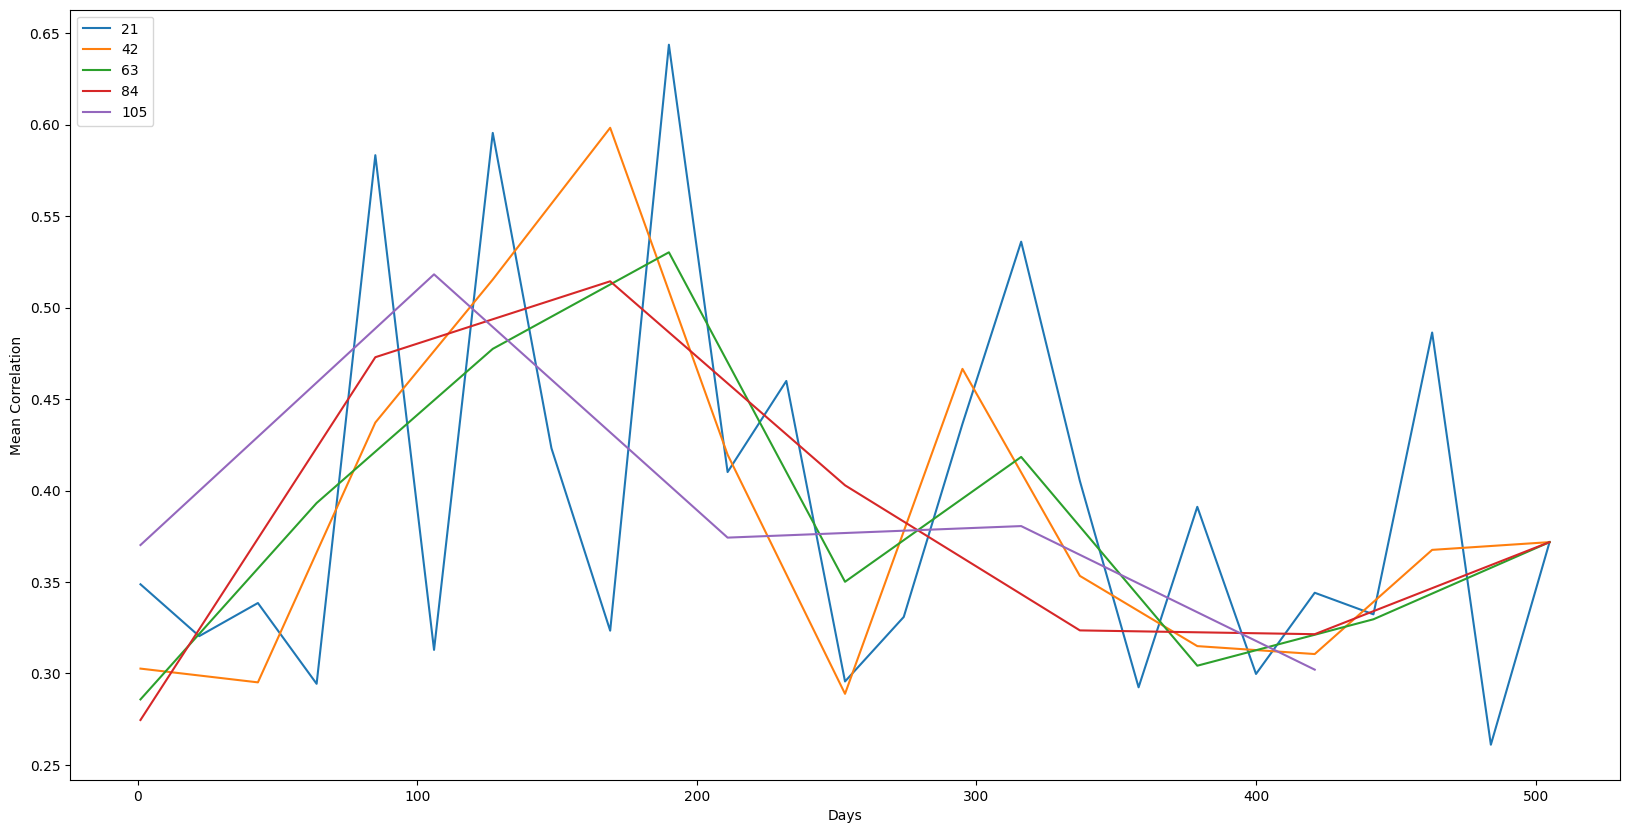

In [18]:
%matplotlib inline
# stocks_cross_corr_dict = {}
#Time Window width
#TO DO: try different windows and different algorithms
#t= 21 #21 based on the paper Asset trees and asset graphs in financial markets J.-P. Onnela et all
# Try window from 1 month to 6 months of trading days
# 21 days is one month trading days
start = 21
end = 126
step = 21;
plt.figure(figsize=(20, 10))
#Find corr for the entire time period 
# _, x_days, y_mean_corr = calculate_corr(df_stock_prices,1,len(df_stock_prices), 'pearson')
# x_days_t = range(0,len(df_stock_prices), 1)
# y_mean_corr_t = np.empty(len(df_stock_prices))
# y_mean_corr_t.fill(y_mean_corr[0])
# plt.plot(x_days_t, y_mean_corr_t)
for t in range(start, end, step):
    x_days = []
    y_mean_corr = []
    W = t
    _, x_days, y_mean_corr = calculate_corr(df_stock_prices,1,W, 'pearson')
    plt.plot(x_days, y_mean_corr)
    plt.xlabel('Days')
    plt.ylabel('Mean Correlation')
    l = list(range(start, end, step))
#     l.insert(0, len(df_stock_prices))
    plt.legend(l, loc='upper left')     

plt.show()

In [19]:
#Calculate corr for the entire period.
stocks_cross_corr, _, _ = calculate_corr(df_stock_prices,1, len(df_stock_prices), 'pearson')
stocks_cross_corr[1]

,NVDA.OQ,AAPL.OQ,MSFT.OQ,AMZN.OQ,GOOGL.OQ,AVGO.OQ,GOOG.OQ,META.OQ,TSLA.OQ,BRKb.N,LLY.N,JPM.N,XOM.N,JNJ.N,WMT.OQ,V.N,COST.OQ,NFLX.OQ,MA.N,CVX.N
NVDA.OQ,1.000000,0.350833,0.387851,0.289031,0.376597,0.376185,0.374220,0.313232,0.226495,0.306202,0.167403,0.317438,0.263566,0.264954,0.163182,0.398648,0.209904,0.213587,0.406438,0.184366
AAPL.OQ,0.350833,1.000000,0.428487,0.330554,0.516781,0.593305,0.511178,0.393402,0.324412,0.238689,0.149669,0.183254,0.098193,0.253937,0.187027,0.490960,0.301380,0.272236,0.469071,0.015316
MSFT.OQ,0.387851,0.428487,1.000000,0.645696,0.785805,0.499933,0.794088,0.680500,0.265911,0.478676,0.348755,0.412677,0.355622,0.436447,0.181241,0.692664,0.376484,0.488978,0.660575,0.135209
AMZN.OQ,0.289031,0.330554,0.645696,1.000000,0.640648,0.411520,0.649301,0.592955,0.315952,0.229882,0.188692,0.175726,0.232742,0.220733,0.096888,0.537184,0.230156,0.502946,0.528170,-0.006697
GOOGL.OQ,0.376597,0.516781,0.785805,0.640648,1.000000,0.482147,0.995599,0.724428,0.321632,0.445948,0.360990,0.400676,0.347501,0.435723,0.142653,0.703184,0.287091,0.555012,0.702348,0.164366
AVGO.OQ,0.376185,0.593305,0.499933,0.411520,0.482147,1.000000,0.471124,0.405424,0.298755,0.134065,0.079424,0.104781,0.094831,0.222495,0.048849,0.481234,0.130531,0.307350,0.382074,-0.019912
GOOG.OQ,0.374220,0.511178,0.794088,0.649301,0.995599,0.471124,1.000000,0.725017,0.322512,0.459140,0.369698,0.403641,0.349010,0.450982,0.151743,0.707308,0.289035,0.546667,0.701232,0.165556
META.OQ,0.313232,0.393402,0.680500,0.592955,0.724428,0.405424,0.725017,1.000000,0.342036,0.276761,0.355556,0.248344,0.252802,0.334624,0.145397,0.656915,0.194031,0.444214,0.621820,0.108961
TSLA.OQ,0.226495,0.324412,0.265911,0.315952,0.321632,0.298755,0.322512,0.342036,1.000000,0.111974,0.197002,0.106361,0.182341,0.311691,0.040043,0.230937,0.192447,0.233683,0.262654,0.082708
BRKb.N,0.306202,0.238689,0.478676,0.229882,0.445948,0.134065,0.459140,0.276761,0.111974,1.000000,0.392531,0.813886,0.499432,0.535795,0.259964,0.467390,0.452375,0.198430,0.360269,0.458885


In [20]:
#Build the Graph with stocks as nodes and corr as edges
import networkx as nx
import networkx.algorithms.community as nxcom
import community

edge_weights = []
def build_graph(stocks_cross_corr, threshold):
    graph_edges = []
    for x in stocks_cross_corr.keys():
        for y in stocks_cross_corr[x].keys():
            #print(x, y) 
            # Filter by absolute value of the corr
            if abs(stocks_cross_corr[x][y]) > threshold:
                #if same stock, continue
                if  x == y:
                    continue
                if x < y: #Avoid duplicates, AxAAL vs AALxA
                    graph_edges.append([x,y,dict(weight=abs(stocks_cross_corr[x][y]))])
                    edge_weights.append(abs(stocks_cross_corr[x][y]))
                else:
                    None

In [21]:
#Community detection using Girvan Newman (GN)
stocks_cross_corr, _, _ = calculate_corr(df_stock_prices,1, len(df_stock_prices), 'pearson')
stocks_cross_corr = stocks_cross_corr[1]
cor_thresold = 0.45

In [22]:
stocks_cross_corr

,NVDA.OQ,AAPL.OQ,MSFT.OQ,AMZN.OQ,GOOGL.OQ,AVGO.OQ,GOOG.OQ,META.OQ,TSLA.OQ,BRKb.N,LLY.N,JPM.N,XOM.N,JNJ.N,WMT.OQ,V.N,COST.OQ,NFLX.OQ,MA.N,CVX.N
NVDA.OQ,1.000000,0.350833,0.387851,0.289031,0.376597,0.376185,0.374220,0.313232,0.226495,0.306202,0.167403,0.317438,0.263566,0.264954,0.163182,0.398648,0.209904,0.213587,0.406438,0.184366
AAPL.OQ,0.350833,1.000000,0.428487,0.330554,0.516781,0.593305,0.511178,0.393402,0.324412,0.238689,0.149669,0.183254,0.098193,0.253937,0.187027,0.490960,0.301380,0.272236,0.469071,0.015316
MSFT.OQ,0.387851,0.428487,1.000000,0.645696,0.785805,0.499933,0.794088,0.680500,0.265911,0.478676,0.348755,0.412677,0.355622,0.436447,0.181241,0.692664,0.376484,0.488978,0.660575,0.135209
AMZN.OQ,0.289031,0.330554,0.645696,1.000000,0.640648,0.411520,0.649301,0.592955,0.315952,0.229882,0.188692,0.175726,0.232742,0.220733,0.096888,0.537184,0.230156,0.502946,0.528170,-0.006697
GOOGL.OQ,0.376597,0.516781,0.785805,0.640648,1.000000,0.482147,0.995599,0.724428,0.321632,0.445948,0.360990,0.400676,0.347501,0.435723,0.142653,0.703184,0.287091,0.555012,0.702348,0.164366
AVGO.OQ,0.376185,0.593305,0.499933,0.411520,0.482147,1.000000,0.471124,0.405424,0.298755,0.134065,0.079424,0.104781,0.094831,0.222495,0.048849,0.481234,0.130531,0.307350,0.382074,-0.019912
GOOG.OQ,0.374220,0.511178,0.794088,0.649301,0.995599,0.471124,1.000000,0.725017,0.322512,0.459140,0.369698,0.403641,0.349010,0.450982,0.151743,0.707308,0.289035,0.546667,0.701232,0.165556
META.OQ,0.313232,0.393402,0.680500,0.592955,0.724428,0.405424,0.725017,1.000000,0.342036,0.276761,0.355556,0.248344,0.252802,0.334624,0.145397,0.656915,0.194031,0.444214,0.621820,0.108961
TSLA.OQ,0.226495,0.324412,0.265911,0.315952,0.321632,0.298755,0.322512,0.342036,1.000000,0.111974,0.197002,0.106361,0.182341,0.311691,0.040043,0.230937,0.192447,0.233683,0.262654,0.082708
BRKb.N,0.306202,0.238689,0.478676,0.229882,0.445948,0.134065,0.459140,0.276761,0.111974,1.000000,0.392531,0.813886,0.499432,0.535795,0.259964,0.467390,0.452375,0.198430,0.360269,0.458885


In [23]:
#stocks_cross_corr
source = []
target = []
weights = []
graph_edges = []
threshold = 0.45
G = nx.Graph()
for x in stocks_cross_corr.keys():
    for y in stocks_cross_corr[x].keys():
        #print(x, y) 
        # Filter by absolute value of the corr
        if abs(stocks_cross_corr[x][y]) > threshold:
            #if same stock, continue
            if  x == y:
                continue
            if x < y: #Avoid duplicates, AxAAL vs AALxA
                #print(stocks_cross_corr[x][y])
                source.append((x, y, abs(stocks_cross_corr[x][y])))
source

[('AAPL.OQ', 'GOOGL.OQ', np.float64(0.5167810789913193)),
 ('AAPL.OQ', 'AVGO.OQ', np.float64(0.5933046918632671)),
 ('AAPL.OQ', 'GOOG.OQ', np.float64(0.5111781903737248)),
 ('AAPL.OQ', 'V.N', np.float64(0.4909599177867773)),
 ('AAPL.OQ', 'MA.N', np.float64(0.4690713507081754)),
 ('MSFT.OQ', 'V.N', np.float64(0.6926637960650122)),
 ('MSFT.OQ', 'NFLX.OQ', np.float64(0.48897797308696095)),
 ('AMZN.OQ', 'MSFT.OQ', np.float64(0.6456956544161967)),
 ('AMZN.OQ', 'GOOGL.OQ', np.float64(0.6406476925743573)),
 ('AMZN.OQ', 'GOOG.OQ', np.float64(0.6493010761359171)),
 ('AMZN.OQ', 'META.OQ', np.float64(0.5929549779947308)),
 ('AMZN.OQ', 'V.N', np.float64(0.5371836221980416)),
 ('AMZN.OQ', 'NFLX.OQ', np.float64(0.5029460750607722)),
 ('AMZN.OQ', 'MA.N', np.float64(0.5281695456709047)),
 ('GOOGL.OQ', 'MSFT.OQ', np.float64(0.7858051921380889)),
 ('GOOGL.OQ', 'META.OQ', np.float64(0.7244281626738951)),
 ('GOOGL.OQ', 'V.N', np.float64(0.7031840096090769)),
 ('GOOGL.OQ', 'NFLX.OQ', np.float64(0.555011574

In [24]:
G = nx.Graph()
G.add_weighted_edges_from(source)

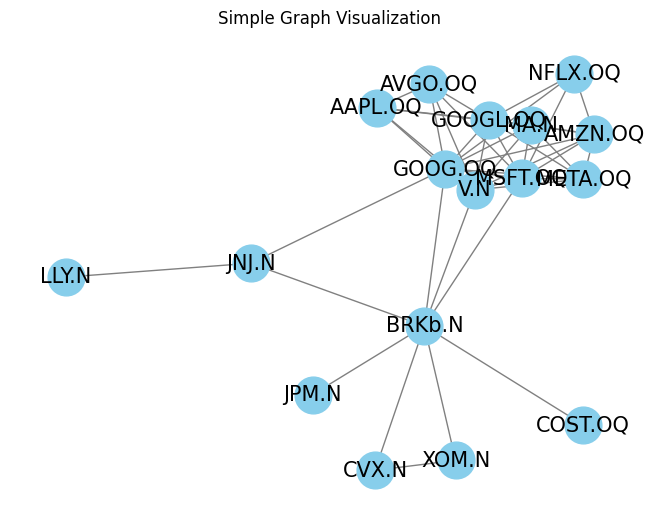

In [25]:
# Draw the graph
nx.draw(G, with_labels=True, node_color='skyblue', node_size=700, font_size=15, font_color='black', edge_color='gray')
plt.title("Simple Graph Visualization")
plt.show()


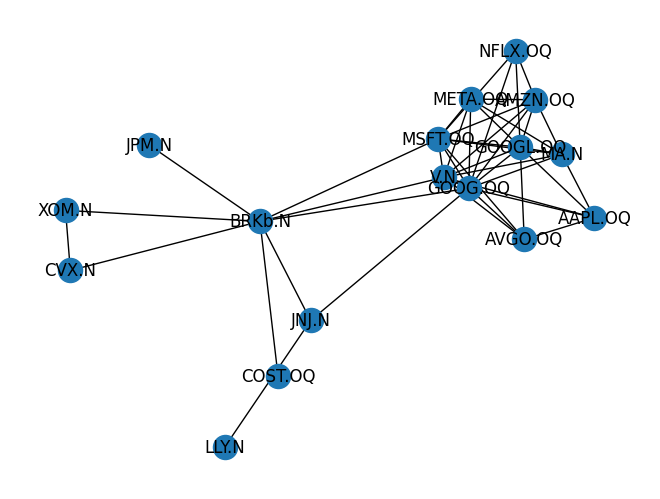

<Figure size 50000x10000 with 0 Axes>

In [26]:
nx.draw(G, with_labels = True)
# Create a new figure with a specific size
plt.figure(figsize=(500, 100))  # Width: 10 inches, Height: 6 inches

plt.show()

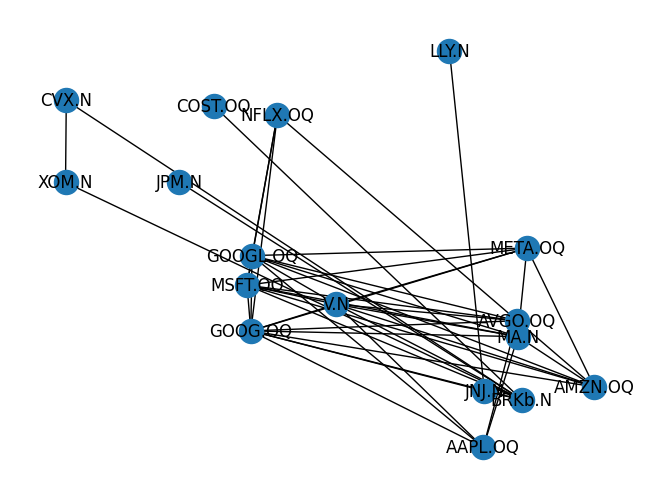

In [27]:
# clearing the current plot
plt.clf()
 
# drawing in planar layout
nx.draw_random(G, with_labels = True)
plt.show()

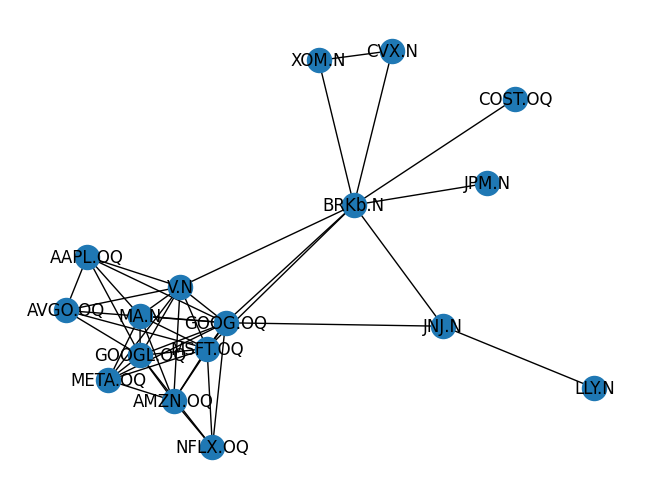

In [28]:
# clearing the current plot
plt.clf()
 
# drawing in spectral layout
nx.draw_spring(G, with_labels = True)
plt.show()